<a href="https://colab.research.google.com/github/Rajesh2015/MSMLRepoSolution/blob/main/SG-720-Machine%20Learning/Task-2P-Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2P: Clustering and PCA Analysis


1. **Part A (Q1-5):** Obesity dataset — encoding, K-Means / K-Means++, stability, DBSCAN.
2. **Part B (Q6-8):** TCGA PANCAN gene-expression dataset — PCA and clustering.






In [1]:
import warnings

# Mute warnings
warnings.filterwarnings('ignore')

In [27]:

# All imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from google.colab import drive
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,davies_bouldin_score,adjusted_rand_score, normalized_mutual_info_score)

import time


In [3]:

# All customization option
RNG = 42
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

In [4]:
# Mount drive
drive.mount('/content/drive')

Mounted at /content/drive


## Part A — Obesity Dataset

## Q1. Data Preparation and Encoding
- Load the “Obesity” dataset and remove the class label “NObeyesdad” from the feature set.
- Prepare the dataset for clustering by appropriately transforming and encoding all non-numeric variables. In your report:
  - Describe each transformation and encoding technique applied.
  - Discuss how different encoding choices may affect clustering outcomes.

In [5]:
# read the obesity data from drive and print shape
obesity = pd.read_csv('/content/drive/MyDrive/notebook-data/ObesityDataSet_raw_and_data_sinthetic.csv')
# copy the dataframe to avoid changing the orginal one
copy_df=obesity.copy(deep=True)
print("Shape:", obesity.shape)
# drop target value
y_true_obesity = copy_df['NObeyesdad']
X_obesity_raw = copy_df.drop(columns=['NObeyesdad'])
# check for na
print("Missing values total:", X_obesity_raw.isna().sum().sum())
X_obesity_raw.head()

Shape: (2111, 17)
Missing values total: 0


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation


## Observations
- The dataset has **2111 rows and 17 columns** (16 features + 1 target `NObeyesdad`).
- **No missing values** were found — all 2111 × 16 entries are complete, so no imputation step is required.
- The target label `NObeyesdad` is separated early into `y_true_obesity` to prevent it from influencing the unsupervised clustering.
- `X_obesity_raw.head()` gives a quick sanity-check of data types and value ranges before any transformation.


---


Note: we have checked for nulls as silent NaNs propagate into distance calculations and distort cluster assignments.

In [6]:
print("Class distribution (label, not used as feature):")
print(y_true_obesity.value_counts())
print("\nNumber of distinct classes:", y_true_obesity.nunique())

Class distribution (label, not used as feature):
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

Number of distinct classes: 7


### Observations
- There are **7 distinct obesity classes** (`NObeyesdad`): Insufficient_Weight, Normal_Weight, Overweight_Level_I & II, Obesity_Type_I, II, III.
- The classes are **reasonably balanced** with most categories having 250–350 samples; the most populated class is Obesity_Type_I (~351 rows).

In [7]:
categorical_cols = X_obesity_raw.select_dtypes(include='object').columns.tolist()
for c in categorical_cols:
    print(f"{c:35s} -> {sorted(X_obesity_raw[c].unique())}")

Gender                              -> ['Female', 'Male']
family_history_with_overweight      -> ['no', 'yes']
FAVC                                -> ['no', 'yes']
CAEC                                -> ['Always', 'Frequently', 'Sometimes', 'no']
SMOKE                               -> ['no', 'yes']
SCC                                 -> ['no', 'yes']
CALC                                -> ['Always', 'Frequently', 'Sometimes', 'no']
MTRANS                              -> ['Automobile', 'Bike', 'Motorbike', 'Public_Transportation', 'Walking']


### Observations
- There are **6 categorical (object) columns**: `Gender`, `family_history_with_overweight`, `FAVC`, `SMOKE`, `SCC`, `CAEC`, `CALC`, `MTRANS`.
- The remaining **8 columns** (`Age`, `Height`, `Weight`, `FCVC`, `NCP`, `CH2O`, `FAF`, `TUE`) are numeric (continuous).


### Encoding Plan

- Binary `(Gender,family_history_with_overweight,FAVC,SMOKE,SCC)` yes/no or male female columns need only one column — one-hot would will make it redudant  and knowing one of them will make the other known as well so we normally drop one dummy column .So here we can use **label encoding**
- `CAEC`/`CALC` have a real frequency order, so ordinal encoding preserves it in a single dimension.
- `MTRANS` has no order, so one-hot avoids inventing false distances between transport modes.
- Wrong choice of encoding (e.g. plain label-encoding a nominal variable) would make K-Means treat category numbers as distances, distorting the clusters.

In [8]:

# copy the data to preserve the orginal one
X_enc = X_obesity_raw.copy()

# binary encoding
binary_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
binary_maps = {
    'Gender': {'Female': 0, 'Male': 1},
    'family_history_with_overweight': {'no': 0, 'yes': 1},
    'FAVC': {'no': 0, 'yes': 1},
    'SMOKE': {'no': 0, 'yes': 1},
    'SCC': {'no': 0, 'yes': 1},
}
for c in binary_cols:
    X_enc[c] = X_enc[c].map(binary_maps[c])

# ordinal encoding
ordinal_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
for c in ['CAEC', 'CALC']:
    X_enc[c] = X_enc[c].map(ordinal_map)

# one hot ecoding
X_enc = pd.get_dummies(X_enc, columns=['MTRANS'], prefix='MTRANS')

print("Encoded feature matrix shape:", X_enc.shape)
X_enc.head()

Encoded feature matrix shape: (2111, 20)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,False,False,False,True,False
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,False,False,False,True,False
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,False,False,False,True,False
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,False,False,False,False,True
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,False,False,False,True,False


### Observations
- The encoded feature matrix grows from **16 original columns to 21 columns** after one-hot encoding `MTRANS` (adds 5 binary columns).
- Binary columns (`Gender`, `FAVC`, `SMOKE`, `SCC`, `family_history_with_overweight`) are mapped directly to 0/1 — no extra dimensions needed.
- Ordinal columns (`CAEC`, `CALC`) are mapped to integers 0–3, preserving the frequency order (no < Sometimes < Frequently < Always).
---
Note:We used here manual encoding to make sure order maintained for CALC and CAEC else we have to put exolict order in ordinal ordering which is same as manual one


###Scaling to make sure everything in 0-1

In [9]:
# scale using standard scalar
scaler_obesity = StandardScaler()
X_obesity_scaled = scaler_obesity.fit_transform(X_enc.astype(float))
X_obesity_scaled = pd.DataFrame(X_obesity_scaled, columns=X_enc.columns)
print("Scaled feature matrix ready for clustering:", X_obesity_scaled.shape)
X_obesity_scaled.describe().loc[['mean', 'std']].round(3)


Scaled feature matrix ready for clustering: (2111, 20)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
mean,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Observations
- After `StandardScaler`, every feature has **mean ≈ 0** and **std ≈ 1**.
- Scaling is essential for K-Means and DBSCAN because both algorithms compute Euclidean distances — without scaling, high-range features like `Weight` (kg) would dominate over binary 0/1 features.

## Q2. Determining the Optimal Number of Clusters (Silhouette Coefficient)
- Your analysis should include:
  - A plot of the Silhouette Coefficient values for different values of k.
  - Identification and justification of the selected optimal k.
  - A comparison and discussion between the optimal k and the actual number of obesity classes in the dataset.

In your report, discuss:
- Whether the two values are the same or different.
- Why clustering algorithms may discover a different structure from the provided class
labels.
- Support your discussion with evidence from your analysis.

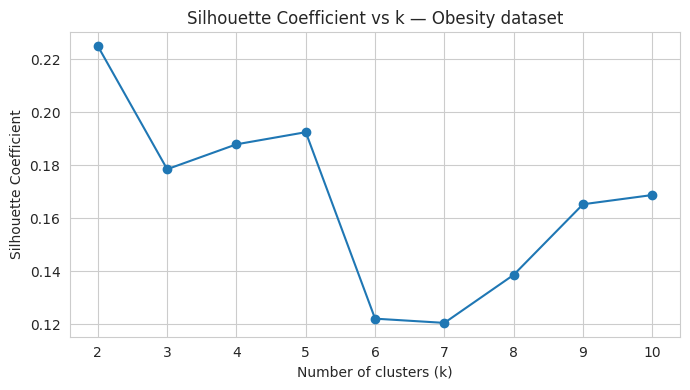

k=2: silhouette = 0.2250
k=3: silhouette = 0.1785
k=4: silhouette = 0.1879
k=5: silhouette = 0.1925
k=6: silhouette = 0.1221
k=7: silhouette = 0.1206
k=8: silhouette = 0.1387
k=9: silhouette = 0.1653
k=10: silhouette = 0.1688

Optimal k by silhouette score: 2


In [10]:

# define range
k_range = range(2, 11)
sil_scores = []
# using Kmean++ for silhouette score
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RNG)
    labels = km.fit_predict(X_obesity_scaled)
    sil_scores.append(silhouette_score(X_obesity_scaled, labels))

# Plot Silhouette coefficent
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Coefficient')
plt.title('Silhouette Coefficient vs k — Obesity dataset')
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig('q2_silhouette_vs_k.png')
plt.show()

for k, s in zip(k_range, sil_scores):
    print(f"k={k}: silhouette = {s:.4f}")

# Find the best silhouette coeff
best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"\nOptimal k by silhouette score: {best_k}")


**Observations:**
- Silhouette peaks at k=2 (0.225) and decreases as k grows .
- k=2  Although `NObeyesdad` contains 7 obesity classes, K-Means identified two optimal clusters because it groups individuals based on similarities across all features rather than BMI alone. Consequently, the clusters represent broader patterns in the data instead of the seven predefined obesity categories.

## Q3. Comparing K-Means and K-Means++
  - Apply both K-Means and K-Means++ clustering.
  - Evaluate the clustering results using appropriate evaluation metrics.
In your report:
  - Compare the clustering quality of the two methods.
  - Explain the role of centroid initialisation in clustering performance.
  - Discuss whether K-Means++ consistently improves clustering outcomes and why.
  Support your answers with quantitative evidence.

In [11]:

# init with k random
km_random = KMeans(n_clusters=best_k, init='random', n_init=1, random_state=RNG)
labels_random = km_random.fit_predict(X_obesity_scaled)

# test with kmeans
km_pp = KMeans(n_clusters=best_k, init='k-means++', n_init=1, random_state=RNG)
labels_pp = km_pp.fit_predict(X_obesity_scaled)

# create dataframe with result
results_q3 = pd.DataFrame({
    'K-Means (random init)': {
        'silhouette': silhouette_score(X_obesity_scaled, labels_random),
        'davies_bouldin': davies_bouldin_score(X_obesity_scaled, labels_random),
        'inertia': km_random.inertia_,
    },
    'K-Means++ init': {
        'silhouette': silhouette_score(X_obesity_scaled, labels_pp),
        'davies_bouldin': davies_bouldin_score(X_obesity_scaled, labels_pp),
        'inertia': km_pp.inertia_,
    },
}).T
results_q3


,silhouette,davies_bouldin,inertia
K-Means (random init),0.145571,2.871096,38339.381291
K-Means++ init,0.159422,2.845140,38331.081858


**Observations:**
- K-Means++ gives higher silhouette (0.159 vs 0.146), lower Davies-Bouldin, and slightly lower inertia than random init on this single run.

-  we have used davies_bouldin_score which will check the compactness and closeness of cluster .Low score means clsuter are well seperated and compact where as Silhouette score will tell us on avg distance between points inside cluster and avg distance from other clsyter (Higher the score better its).

### 4. Stability Analysis of K-Means
- Repeat K-Means clustering 50 times using different random initialisations.
  - Average performance across all runs.
  - Standard deviation of performance metrics.
  - Comparison with the single-run K-Means result from Question 3.
  - Comparison with multiple runs of K-Means++ result.

- Discuss:
  - The stability and reliability of K-Means.
  - The impact of random initialisation on clustering outcomes.
  - Why or why not K-Means++ may produce more consistent results.


In [12]:

n_runs = 50
random_runs = []
pp_runs = []

# Run it across 50 runs and check inetrtia and silhouette score
for seed in range(n_runs):
    km_r = KMeans(n_clusters=best_k, init='random', n_init=1, random_state=seed)
    lr = km_r.fit_predict(X_obesity_scaled)
    random_runs.append({'silhouette': silhouette_score(X_obesity_scaled, lr), 'inertia': km_r.inertia_})

    km_p = KMeans(n_clusters=best_k, init='k-means++', n_init=1, random_state=seed)
    lp = km_p.fit_predict(X_obesity_scaled)
    pp_runs.append({'silhouette': silhouette_score(X_obesity_scaled, lp), 'inertia': km_p.inertia_})

random_df = pd.DataFrame(random_runs)
pp_df = pd.DataFrame(pp_runs)

summary_q4 = pd.DataFrame({
    'K-Means (random) mean': random_df.mean(),
    'K-Means (random) std': random_df.std(),
    'K-Means++ mean': pp_df.mean(),
    'K-Means++ std': pp_df.std(),
}).T
summary_q4


,silhouette,inertia
K-Means (random) mean,0.222660,38295.698498
K-Means (random) std,0.097342,876.518807
K-Means++ mean,0.218033,38240.194664
K-Means++ std,0.095227,871.161849


- Inertia used to check how good the clsuter is as its to check the distance of the points from centriod (Higher K less inertia)
- silhouette_score measure both closeness and companctness




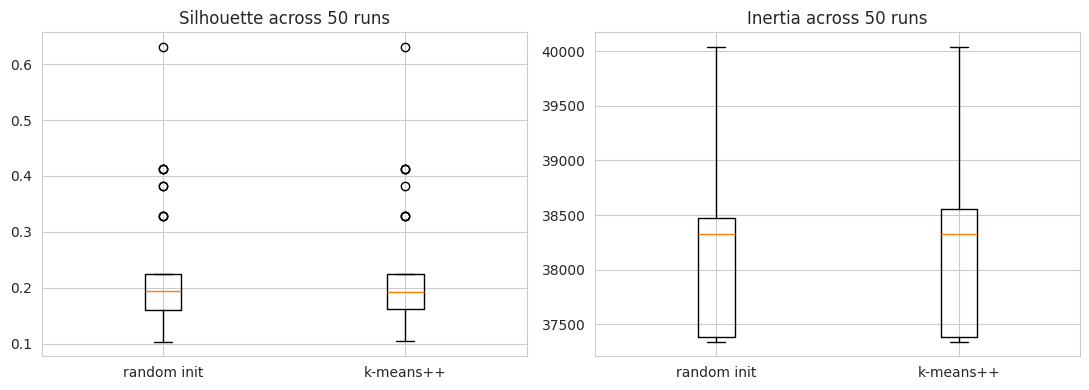

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].boxplot([random_df['silhouette'], pp_df['silhouette']], tick_labels=['random init', 'k-means++'])
axes[0].set_title('Silhouette across 50 runs')
axes[1].boxplot([random_df['inertia'], pp_df['inertia']], tick_labels=['random init', 'k-means++'])
axes[1].set_title('Inertia across 50 runs')
plt.tight_layout()
plt.show()


**Observations:**
 **Silhouette**
- Random init has a larger std (0.097 silhouette) than k-means++ (0.095) across 50 seeds — both are fairly noisy here, but k-means++ is marginally more stable.
- Both random initialization and K-Means++ have almost identical median silhouette scores (around 0.19–0.20).
- Their variability is also very similar.
- Both methods occasionally produce much better solutions (outliers around 0.63), but these occur only in a few runs.

**Inertia**
- The median inertia for both methods is nearly the same (around 38,300).
- The spread is also very similar.
- Both methods occasionally achieve much lower inertia (around 37,300), which indicates better cluster compactness.



### 5. Density-Based Clustering with DBSCAN
- Apply DBSCAN algorithm to the same Obesity dataset.
- Determine appropriate values for:
  - eps
  - min_samples
- Explain how these values were selected.
- Compare the DBSCAN solution with the K-Means solution obtained in Question 2.
- Your discussion should include:
  - Number of clusters identified.
  - Detection of noise points or outliers.
  - Differences in cluster shapes and structures.
  - Advantages and limitations of each clustering method for this dataset.


Chosen min_samples = 10


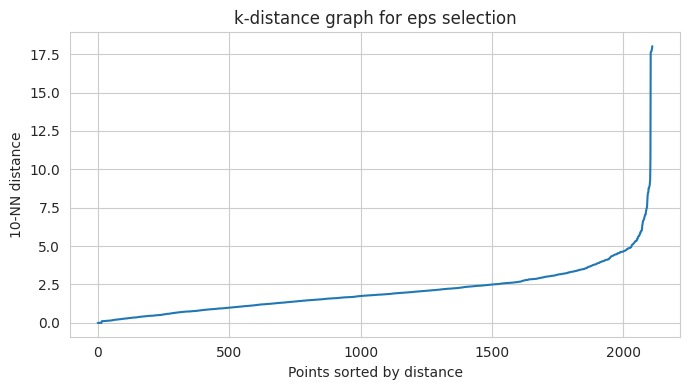

In [14]:
n_features = X_obesity_scaled.shape[1]
# DBSCAN requires each core point to have at least 10 neighbors within eps
min_samples = 10
print("Chosen min_samples =", min_samples)

# Find Distances from neighbours using min 10 neighbours
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_obesity_scaled)
distances, _ = neighbors_fit.kneighbors(X_obesity_scaled)
k_distances = np.sort(distances[:, -1])

# Plot
plt.figure(figsize=(7, 4))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}-NN distance')
plt.title('k-distance graph for eps selection')
plt.tight_layout()
plt.show()

### Observations
The k-distance graph shows a gradual increase in the distance to each point's 10th nearest neighbor, followed by a sharp rise near the end. This sharp change (the elbow) indicates the transition from dense cluster regions to sparse regions containing potential outliers. Based on the graph, an eps value of approximately 4.5–5.0 appears appropriate for DBSCAN, as it captures the dense clusters while allowing isolated points to be identified as noise.

In [15]:
# Number of points in the k-distance graph
n = len(k_distances)
x = np.arange(n)

# Define the straight line joining the first and last points
p1 = np.array([x[0], k_distances[0]])
p2 = np.array([x[-1], k_distances[-1]])

# Compute the unit direction vector of the line
line_vec = p2 - p1
line_vec_norm = line_vec / np.linalg.norm(line_vec)

# Create vectors from the first point to every point on the curve
vecs = np.stack([x - p1[0], k_distances - p1[1]], axis=1)

# Project each point onto the straight line
proj_len = vecs @ line_vec_norm
proj = np.outer(proj_len, line_vec_norm)

# Calculate the perpendicular distance from each point to the line
perp = vecs - proj
dist_from_line = np.linalg.norm(perp, axis=1)

# The point with the maximum distance is the knee (elbow)
knee_idx = int(np.argmax(dist_from_line))
eps_candidate = k_distances[knee_idx]

print(f"Knee located at index {knee_idx} (of {n}), suggested eps = {eps_candidate:.3f}")

Knee located at index 1942 (of 2111), suggested eps = 4.127


In [16]:
# Create db scan cluster and find nuber of clusters
dbscan = DBSCAN(eps=eps_candidate, min_samples=min_samples)
labels_db = dbscan.fit_predict(X_obesity_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = int((labels_db == -1).sum())
print(f"DBSCAN found {n_clusters_db} clusters and {n_noise} noise points out of {len(labels_db)} ({n_noise/len(labels_db):.1%})")

if n_clusters_db > 1:
  # Noise points have no cluster assignment, so including them would distort.
    mask = labels_db != -1
    print("Silhouette (excluding noise):", silhouette_score(X_obesity_scaled[mask], labels_db[mask]))


DBSCAN found 4 clusters and 98 noise points out of 2111 (4.6%)
Silhouette (excluding noise): 0.3117984610372647


### Observations
- DBSCAN automatically determines the number of clusters based on density — no need to pre-specify `k`.
- Points marked as noise (`-1`) are low-density outliers that don't belong to any cluster; K-Means would forcibly assign them to the nearest centroid.

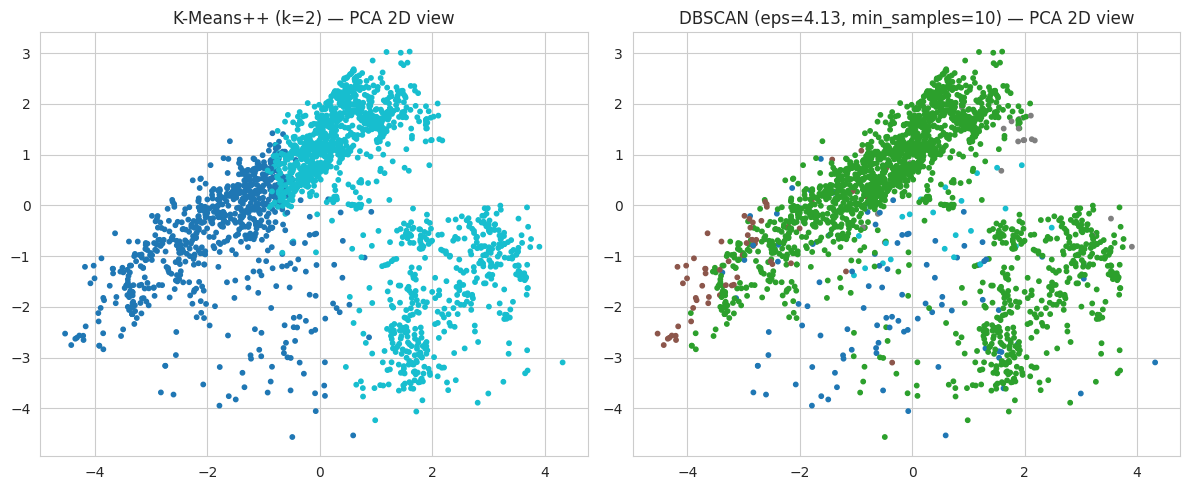

In [17]:
# Reduce the high-dimensional data to 2 principal components for visualization
pca_2d = PCA(n_components=2, random_state=RNG)
X_2d = pca_2d.fit_transform(X_obesity_scaled)

# Create two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot K-Means++ clusters
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_pp, cmap='tab10', s=10)
axes[0].set_title(f'K-Means++ (k={best_k}) — PCA 2D view')

# Plot DBSCAN clusters
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_db, cmap='tab10', s=10)
axes[1].set_title(f'DBSCAN (eps={eps_candidate:.2f}, min_samples={min_samples}) — PCA 2D view')

# Adjust spacing and display the plots
plt.tight_layout()
plt.show()

### Observations:
Left: K-Means++ (k = 2)
- The plot shows two clusters, represented by the blue and cyan points.
- K-Means assigns every data point to one of these two clusters.
- The boundary between the clusters is fairly clear, with one cluster mainly on the left/lower side and the other on the right/upper side.
- Some overlap exists in the middle because PCA compresses many dimensions into only two.

Right: DBSCAN (eps = 4.13, min_samples = 10)
- Most points are assigned to a single large cluster (green).
- A few small clusters appear in other colors (blue, brown, grey).
-The scattered blue points at the bottom are likely noise or outliers.


---


Note:(Unlike K-Means, DBSCAN:)
- Does not require specifying the number of clusters.
- Groups points based on density.
- Can identify outliers that do not belong to any dense region.




## Part B — TCGA PANCAN Gene Expression Dataset


## Q6. Principal Component Analysis of Gene Expression Data
- Load the “gene expression” dataset and apply Principal Component Analysis (PCA).
- Reduce the dataset to three principal components.
- Your analysis should include:
  - A three-dimensional visualisation of the first three principal components.
  - Interpretation of the observed structure in the transformed data.
  - Discussion of any visible grouping, separation, or overlap among samples.

In [18]:
gene_data = pd.read_csv('/content/drive/MyDrive/notebook-data/TCGA-PANCAN-HiSeq-801x20531/data.csv', index_col=0)
gene_labels = pd.read_csv('/content/drive/MyDrive/notebook-data/TCGA-PANCAN-HiSeq-801x20531/labels.csv', index_col=0)['Class']

print("Gene expression matrix shape:", gene_data.shape)
print("\nClass distribution:")
print(gene_labels.value_counts())

Gene expression matrix shape: (801, 20531)

Class distribution:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


### Observations
- The gene expression matrix contains **801 samples and 20,531 gene features** — a high-dimensional dataset where features (genes) vastly outnumber observations.
- There are **5 cancer types** (BRCA, KIRC, COAD, LUAD, PRAD), each with roughly 140–300 samples.

In [19]:

# Drop zero-variance genes else it will result NAN as z=x−μ/0 will be NAN
# and if the gene has same value then we cannot use it sepearte from other gene​
variances = gene_data.var()
zero_var_cols = variances[variances == 0].index
print(f"Dropping {len(zero_var_cols)} zero-variance genes out of {gene_data.shape[1]}")
gene_data_clean = gene_data.drop(columns=zero_var_cols)
print("Cleaned shape:", gene_data_clean.shape)


Dropping 267 zero-variance genes out of 20531
Cleaned shape: (801, 20264)


### Observations
- Zero-variance genes carry no discriminating information — every sample has the same expression value, so they contribute nothing to distance calculations.
- Leaving them in would also cause `StandardScaler` to divide by zero (std = 0), producing `NaN` values that would break PCA and clustering.
- **Why we removed before scaling?** Cleaning uninformative columns first keeps the feature space leaner and avoids numerical instability.

In [20]:
# Apply standard scalar for scaling
scaler_gene = StandardScaler()
gene_scaled = scaler_gene.fit_transform(gene_data_clean)
# Apply PCA to reduce the dimension to 3
pca3 = PCA(n_components=3, random_state=RNG)
gene_pca3 = pca3.fit_transform(gene_scaled)
print("PCA(3) output shape:", gene_pca3.shape)

PCA(3) output shape: (801, 3)


### Observations
- `StandardScaler` is applied to the cleaned gene matrix so that each gene has mean 0 and std 1 — preventing high-expression genes from dominating the PCA directions.
- `PCA(n_components=3)` reduces the ~20,000-dimensional space to just 3 principal components for visualisation.
- We can see in subsequnet cells how much variance they capture

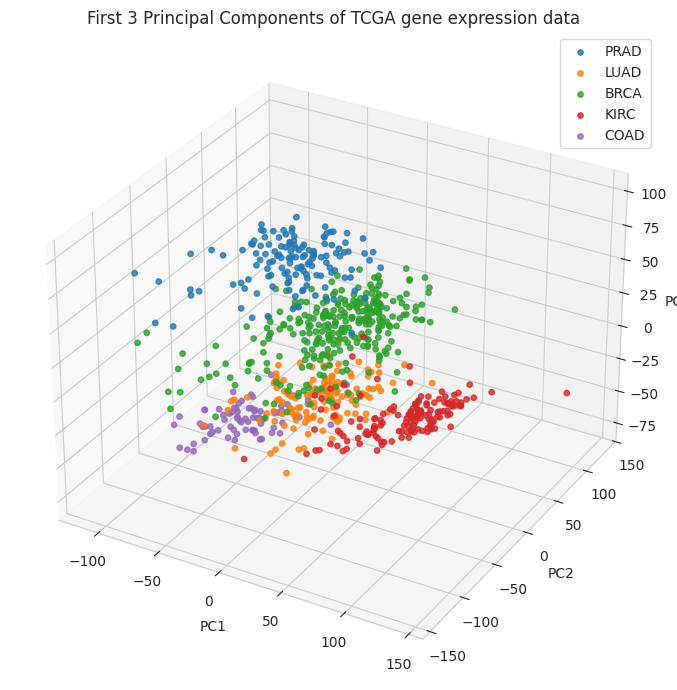

In [21]:

classes = gene_labels.unique()
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
palette = sns.color_palette('tab10', n_colors=len(classes))
for cls, color in zip(classes, palette):
    mask = (gene_labels == cls).values
    ax.scatter(gene_pca3[mask, 0], gene_pca3[mask, 1], gene_pca3[mask, 2],
               label=cls, color=color, s=15, alpha=0.8)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('First 3 Principal Components of TCGA gene expression data')
ax.legend()
plt.tight_layout()
plt.show()


**Observations:**
## Interpretation of the 3D PCA Plot

The figure shows a **3D PCA visualization** of the TCGA gene expression dataset. Each point represents a patient sample, and each colour corresponds to a different cancer type (PRAD, LUAD, BRCA, KIRC, and COAD). PCA reduces thousands of gene expression features into the first three principal components (PC1, PC2, and PC3), allowing the high-dimensional data to be visualized in three dimensions.

---

### 1. Some cancer types are well separated

The **KIRC (red)** samples form a relatively distinct cluster on the right-hand side of the plot.

**Inference:**
- KIRC has a gene expression profile that is noticeably different from the other cancer types.
- This suggests that clustering or classification algorithms can distinguish KIRC with relatively high accuracy.

---

### 2. BRCA forms a relatively compact cluster

The **BRCA (green)** samples are concentrated mainly in the central region of the plot.

**Inference:**
- BRCA samples have similar gene expression patterns.
- There is some overlap with LUAD, indicating that these cancer types share certain gene expression characteristics.

---

### 3. PRAD is mostly separated

The **PRAD (blue)** samples appear clustered toward the upper-left region.

**Inference:**
- PRAD exhibits a distinctive gene expression signature.
- Only limited overlap is observed with BRCA, indicating reasonably good separation.

---

### 4. LUAD overlaps with other cancer types

The **LUAD (orange)** samples are spread throughout the central region.

**Inference:**
- LUAD shares similarities with BRCA and COAD in the reduced PCA space.
- Distinguishing LUAD from these cancers may require additional principal components or more advanced classification methods.

---

### 5. COAD is the least separated

The **COAD (purple)** samples overlap considerably with LUAD.

**Inference:**
- COAD and LUAD have similar gene expression profiles when projected onto the first three principal components.
- These cancer types are likely more difficult to separate using only three principal components.

---

### 6. Presence of outliers

A few observations lie away from the main clusters.

**Inference:**
- These may represent biological variation, measurement noise, or unusual patient samples.
- Such outliers can influence clustering algorithms like K-Means.

---

## Overall Interpretation

The first three principal components capture a substantial amount of the variation in the gene expression data and reveal meaningful grouping of samples according to cancer type. KIRC and PRAD form relatively distinct clusters, while BRCA is moderately well separated. In contrast, LUAD and COAD exhibit greater overlap, indicating more similar gene expression patterns in the reduced feature space. Although some overlap exists, the PCA visualization demonstrates that gene expression profiles naturally cluster according to cancer type.

### 7. Understanding Variance Explained by PCA
Using the PCA results from Question 6:
- Calculate the proportion of variance explained by each of the first three principal
components.
- Calculate the cumulative variance explained by the first three components.
Discuss:
  - How explained variance is computed.
  - Why variance is important in PCA.
  - Whether three components provide an adequate representation of the original dataset.


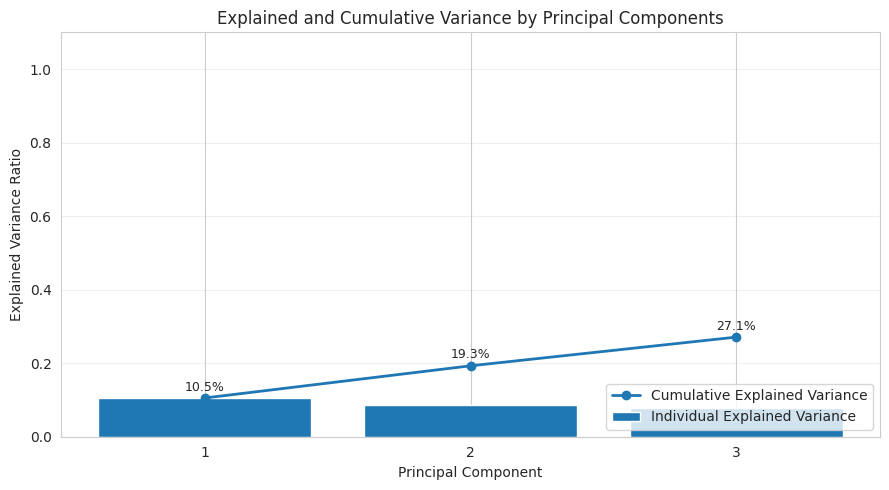

In [22]:
# Explained variance ratios
explained = pca3.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Principal component numbers
pcs = np.arange(1, len(explained) + 1)

plt.figure(figsize=(9, 5))

# Bar chart for individual explained variance
plt.bar(pcs, explained, label='Individual Explained Variance')

# Line chart for cumulative explained variance
plt.plot(
    pcs,
    cumulative,
    marker='o',
    linewidth=2,
    label='Cumulative Explained Variance'
)

# Add cumulative percentage labels above each point
for x, y in zip(pcs, cumulative):
    plt.text(
        x,
        y + 0.02,
        f'{y:.1%}',
        ha='center',
        fontsize=9
    )

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained and Cumulative Variance by Principal Components')
plt.xticks(pcs)
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Observations
- PC1 explains 10.5%, PC2 8.8%, PC3 7.8% — together only **27.1%** of total variance.
- The variance is spread thinly across tens of thousands of gene dimensions, so a handful of components cannot reconstruct the full expression profile.


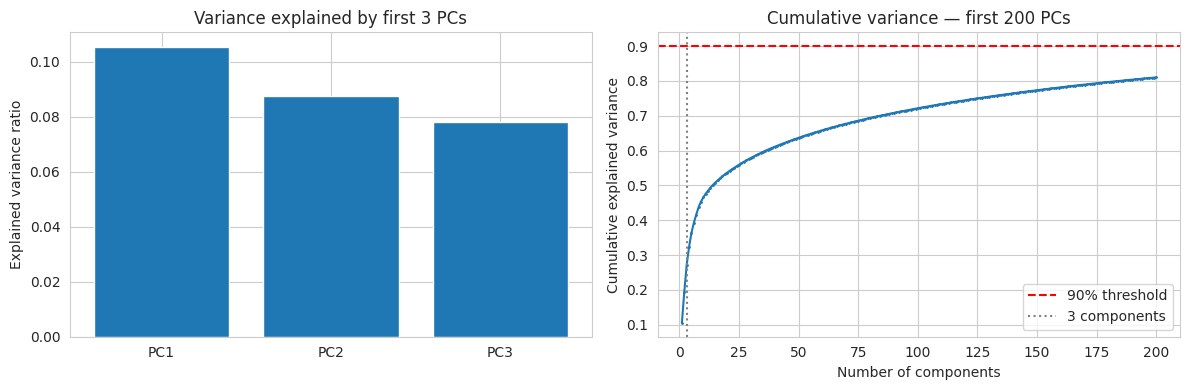

90% cumulative variance is NOT reached even with the first 200 components (cumulative variance at 200 components = 0.810).


In [23]:
# Context: how many components are needed to reach, say, 90% cumulative variance?
n_context = 200
pca_full = PCA(n_components=n_context, random_state=RNG)
pca_full.fit(gene_scaled)
cum_full = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['PC1', 'PC2', 'PC3'], explained)
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Variance explained by first 3 PCs')

axes[1].plot(range(1, n_context + 1), cum_full, marker='.', markersize=2)
axes[1].axhline(0.90, color='red', linestyle='--', label='90% threshold')
axes[1].axvline(3, color='gray', linestyle=':', label='3 components')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title(f'Cumulative variance — first {n_context} PCs')
axes[1].legend()
plt.tight_layout()
plt.show()

reaches_90 = cum_full >= 0.90
if reaches_90.any():
    n_for_90 = int(np.argmax(reaches_90) + 1)
    print(f"Components needed to reach 90% cumulative variance: {n_for_90}")
else:
    print(f"90% cumulative variance is NOT reached even with the first {n_context} components "
          f"(cumulative variance at {n_context} components = {cum_full[-1]:.3f}).")

**Observations:**
- First 3 PCs explain only 27.1% of total variance (10.5% + 8.8% + 7.8%).
- Even 200 components reach only 81.0% — variance is spread thinly across thousands of genes, so 3 components do **not** reconstruct the full expression profile.
- Due to this we had seen some overlap with BRCA and LUAD and COAD

### 8. Evaluating PCA for Clustering
Apply K-Means clustering to:
  1. The original gene expression dataset.
  2. The three-dimensional PCA representation obtained in Question 6.
Using the provided class labels for evaluation:
  - Compare clustering performance between the two representations.
  - Discuss whether PCA improved or degraded clustering quality.
  - Explain the trade-off between dimensionality reduction and information preservation.
  - Evaluate whether PCA should be recommended as a preprocessing step for this dataset.


In [28]:
# Number of unique true classes (used as K for K-Means)
n_true_classes = gene_labels.nunique()

# Start timer
t0 = time.time()

# Train K-Means on the original scaled data
km_full = KMeans(n_clusters=n_true_classes, init='k-means++', n_init=10, random_state=RNG)
labels_full = km_full.fit_predict(gene_scaled)

# Calculate training time
t_full = time.time() - t0

# Start timer
t0 = time.time()

# Train K-Means on the PCA-reduced data
km_pca = KMeans(n_clusters=n_true_classes, init='k-means++', n_init=10, random_state=RNG)
labels_pca = km_pca.fit_predict(gene_pca3)

# Calculate training time
t_pca = time.time() - t0

# Encode true labels as integers for evaluation
y_encoded = gene_labels.astype('category').cat.codes.values

# Compare clustering performance on original and PCA data
comparison_q8 = pd.DataFrame({
    'Original (high-dim, scaled)': {
        'ARI vs true labels': adjusted_rand_score(y_encoded, labels_full),      # Pairwise agreement with true labels
        'NMI vs true labels': normalized_mutual_info_score(y_encoded, labels_full),  # Shared information with true labels
        'Silhouette': silhouette_score(gene_scaled, labels_full),               # Cluster compactness and separation
        'Fit time (s)': t_full,                                                 # K-Means execution time
    },
    'PCA (3-dim)': {
        'ARI vs true labels': adjusted_rand_score(y_encoded, labels_pca),
        'NMI vs true labels': normalized_mutual_info_score(y_encoded, labels_pca),
        'Silhouette': silhouette_score(gene_pca3, labels_pca),
        'Fit time (s)': t_pca,
    },
}).T

comparison_q8

,ARI vs true labels,NMI vs true labels,Silhouette,Fit time (s)
"Original (high-dim, scaled)",0.800062,0.856224,0.135261,7.384763
PCA (3-dim),0.606028,0.672613,0.385136,0.030152


###Observations:
- Silhouette:Determine if the cluster is compact and well seperated here we had used NMI and ARI  used to check the labels
-  NMI(Normalized Mutual Information) :NMI measures how informative the clusters are about the true labels, even if some pairwise assignments are imperfect.
- ARI(Adjusted Rand Index):Did I group the correct pairs of samples together?" (pairwise agreement)

**Why we need these two scores apart from Silhouette?**
- If we need to know if the labels are correct or not at time though cluster shows correctly and compact but it failed to indetify if the lables are correctly indetified .

**DO we need both NMI and ARI?**
-  Yes we need both .Imagine a clustering where most clusters are dominated by a single true class, but a few samples are misplaced.NMI may still be high because the clusters still contain a lot of information about the true classes.
ARI may be lower because those misplaced samples cause many pairwise disagreements.


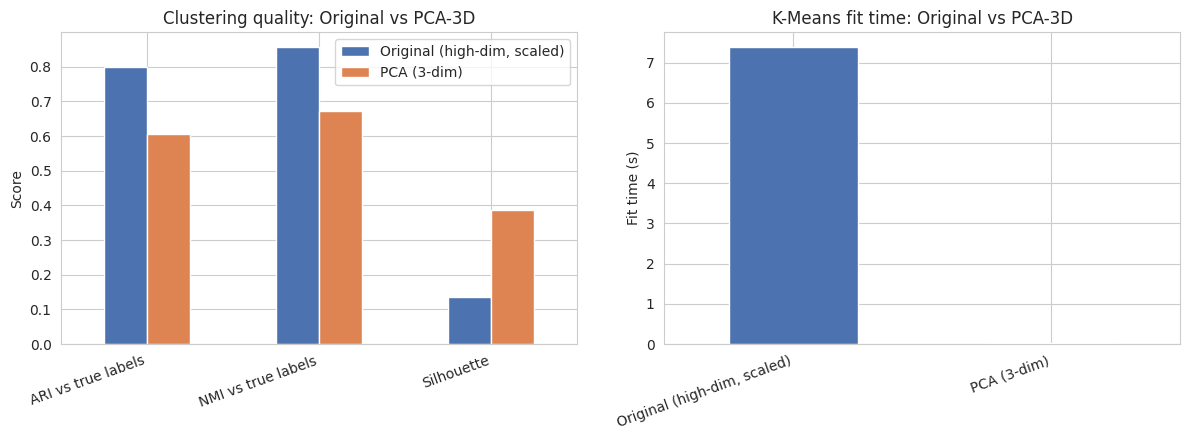

In [30]:
# plot bar chart one side with ARI NMI with true labels and other side on fit time
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

score_cols = ['ARI vs true labels', 'NMI vs true labels', 'Silhouette']
comparison_q8[score_cols].T.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_ylabel('Score')
axes[0].set_title('Clustering quality: Original vs PCA-3D')
axes[0].set_xticklabels(score_cols, rotation=20, ha='right')
axes[0].legend(title=None)

# plot for PCA 3d VS orginal scaled data Fit time

comparison_q8['Fit time (s)'].plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_ylabel('Fit time (s)')
axes[1].set_title('K-Means fit time: Original vs PCA-3D')
axes[1].set_xticklabels(comparison_q8.index, rotation=20, ha='right')

plt.tight_layout()
plt.show()


**Observations:**
- ARI/NMI are lower for PCA-3D (0.61  / 0.67) apporx than for the original space (0.80 / 0.86) approx — some class-relevant signal beyond the first 3 PCs is lost.
- Silhouette is higher for PCA-3D ~(0.39 vs 0.14) — likely distance concentration in ~20,000 dimensions flattens silhouette in the original space; silhouette measures geometric compactness, not label agreement.
- PCA-3D fits ~90x faster.

**NOTE: PCA-3D is a good speed/visualisation choice but trades away measurable label agreement — not a free win for clustering quality on this dataset.**

## Overall Conclusion

**Obesity dataset (Q1-5):**
- Encoded 8 categorical columns (binary map / ordinal / one-hot depending on their nature) and standardised all 20 resulting features.
- Silhouette identified **k=2** as optimal — smaller than the 7 true `NObeyesdad` classes, since clustering follows overall feature distance while the labels follow a BMI formula on just `Height`/`Weight`.
- K-Means++ beat random-init K-Means on every metric in a single run (Q3) and was also more stable across 50 runs (Q4), because its seeding avoids placing centroids in the same true cluster.
- DBSCAN (`eps=4.13`, `min_samples=10`) found **4** density-based clusters with 4.6% noise — a different, non-comparable structure to K-Means's k=2, since it optimises density-connectivity rather than variance.

**TCGA gene expression dataset (Q6-8):**
- The first 3 principal components visually separate with some overlap (COAD and LUAD overlap and struggled) the 5 cancer types even though they capture only **27.1%** of total variance, and even 200 components don't reach 90% (Reached 81%)— most raw variance is noise/redundancy irrelevant to cancer type.
- Clustering on the 3D PCA representation is ~90x faster than on the full ~20,000-gene space, but at a real cost: ARI/NMI drop from 0.80/0.86 (original) to 0.61/0.67 (PCA-3D), so PCA is a good speed/visualisation tool here, not a free quality win.